In [20]:
# https://builtin.com/data-science/time-series-forecasting-python

# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
#!pip install statsmodels
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 7.0 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 12.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.1 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -----------

In [2]:
# importing pandas module  
import pandas as pd 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import datetime

import matplotlib
    
# making data frame  
df=pd.read_csv("Nat_Gas.csv")
print(df.head())


      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9


In [3]:
df['Dates'] = pd.to_datetime(df['Dates'])
df.index = pd.to_datetime(df['Dates'], format='%m/%d/%Y')
del df['Dates']

C:\Users\benjp\AppData\Local\Temp\ipykernel_6128\850188701.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


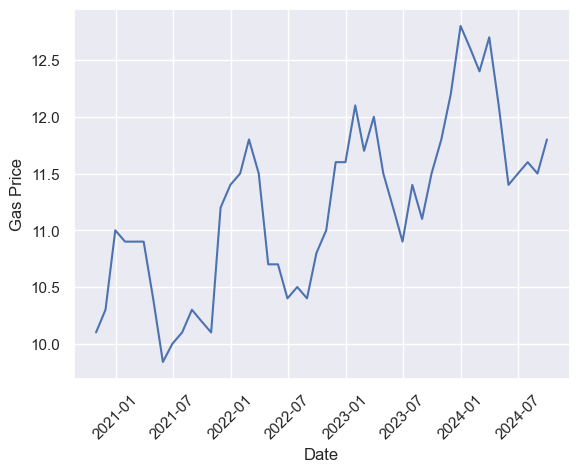

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.ylabel('Gas Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.plot(df.index, df['Prices'], )

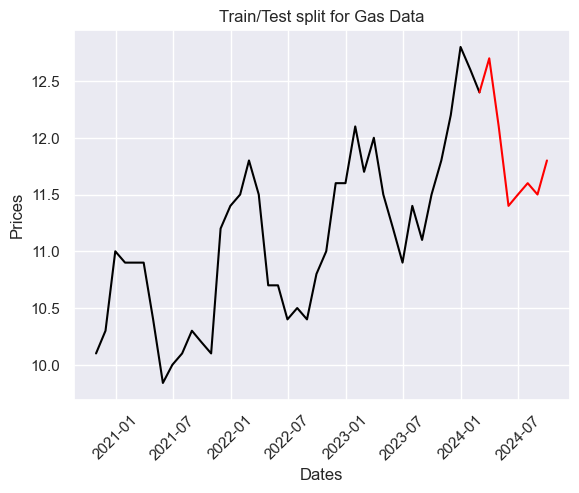

In [27]:
train = df[df.index <= pd.to_datetime("2/29/2024", format='%m/%d/%Y')]
test = df[df.index >= pd.to_datetime("2/29/2024", format='%m/%d/%Y')]

plt.plot(train, color = "black")
plt.plot(test, color = "red")
plt.ylabel('Prices')
plt.xlabel('Dates')
plt.xticks(rotation=45)
plt.title("Train/Test split for Gas Data")
plt.show()

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [29]:
y = train['Prices']

In [30]:
ARMAmodel = SARIMAX(y, order = (1, 0, 1))

C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [31]:
# Fit our model:
ARMAmodel = ARMAmodel.fit()


C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [32]:
y_pred = ARMAmodel.get_forecast(len(test.index))
y_pred_df = y_pred.conf_int(alpha = 0.05) 
y_pred_df["Predictions"] = ARMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = test.index
y_pred_out = y_pred_df["Predictions"] 

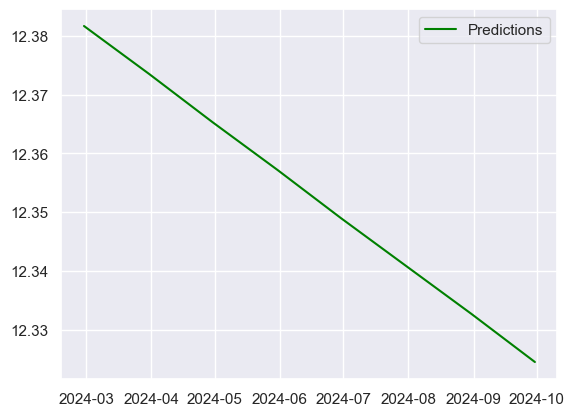

In [33]:
plt.plot(y_pred_out, color='green', label = 'Predictions')
plt.legend()

In [34]:
# evaluate performance
import numpy as np
from sklearn.metrics import mean_squared_error

arma_rmse = np.sqrt(mean_squared_error(test["Prices"].values, y_pred_df["Predictions"]))
print("RMSE: ",arma_rmse)

RMSE:  0.6452976021705396


In [35]:
from statsmodels.tsa.arima.model import ARIMA


C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Dev\jpmc\jpmc\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting par

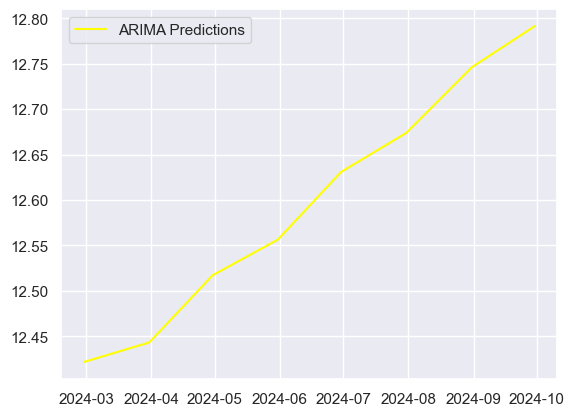

In [36]:
ARIMAmodel = ARIMA(y, order = (2, 2, 2))
ARIMAmodel = ARIMAmodel.fit()

y_pred = ARIMAmodel.get_forecast(len(test.index))
y_pred_df = y_pred.conf_int(alpha = 0.05) 
y_pred_df["Predictions"] = ARIMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = test.index
y_pred_out = y_pred_df["Predictions"] 
plt.plot(y_pred_out, color='Yellow', label = 'ARIMA Predictions')
plt.legend()

In [37]:
arma_rmse = np.sqrt(mean_squared_error(test["Prices"].values, y_pred_df["Predictions"]))
print("RMSE: ",arma_rmse)

RMSE:  0.9044877693493439


In [1]:
model = SARIMAX(y, order = (1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()

# Forecast future values
forecast = model_fit.forecast(steps=10)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(series, label='Observed')
plt.plot(forecast, label='Forecast', color='red')
plt.title('SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

NameError: name 'SARIMAX' is not defined